# Model Evaluation & Explainability

## Objective

In this notebook, we evaluate the final trained model on the test dataset and understand how it makes predictions.

We will:

- Load the saved preprocessing pipeline
- Load the best trained model
- Generate predictions
- Evaluate performance
- Interpret model behavior
- Extract business insights

In [2]:
# =====================================================
# Import Libraries
# =====================================================

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [3]:
# =====================================================
# Load Artifacts
# =====================================================

preprocessor = joblib.load("artifacts/preprocessor.pkl")
best_model = joblib.load("artifacts/best_model.pkl")

print("Artifacts Loaded Successfully.")
print(type(best_model))

Artifacts Loaded Successfully.
<class 'xgboost.sklearn.XGBRegressor'>


# Load Dataset & Prepare Test Data

## Objective

To evaluate the trained model, we need the same test dataset that was used during model training.

In this step, we will:

- Load the cleaned dataset
- Separate features and target variable
- Perform the same train-test split
- Apply the saved preprocessing pipeline
- Generate processed test features for model evaluation

This ensures that the evaluation process is reproducible and consistent with the training pipeline.

In [4]:
# =====================================================
# Load Dataset & Prepare Test Data
# =====================================================

from sklearn.model_selection import train_test_split

# Load cleaned dataset
df = pd.read_csv("Dataset/Clean_Dataset.csv")

# Separate Features and Target
X = df.drop(columns=["price"])
y = df["price"]

# Same Train-Test Split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Apply saved preprocessing pipeline
X_test_processed = preprocessor.transform(X_test)

print("=" * 60)
print("Test Data Prepared Successfully")
print("=" * 60)

print(f"Test Samples : {X_test.shape[0]}")
print(f"Features      : {X_test.shape[1]}")
print(f"Processed Shape : {X_test_processed.shape}")

Test Data Prepared Successfully
Test Samples : 60031
Features      : 11
Processed Shape : (60031, 37)


# Generate Predictions

## Objective

After preparing the processed test dataset, the next step is to generate predictions using the trained machine learning model.

This step includes:

- Predicting flight ticket prices
- Creating a comparison table
- Comparing actual and predicted values

This comparison serves as the foundation for all further evaluation and explainability analyses.

In [5]:
# =====================================================
# Generate Predictions
# =====================================================

# Generate Predictions
y_pred = best_model.predict(X_test_processed)

# Create Prediction DataFrame
prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Calculate Prediction Error
prediction_df["Error"] = (
    prediction_df["Actual Price"] -
    prediction_df["Predicted Price"]
)

prediction_df["Absolute Error"] = (
    prediction_df["Error"].abs()
)

print("=" * 60)
print("Predictions Generated Successfully")
print("=" * 60)

prediction_df.head(10)

Predictions Generated Successfully


,Actual Price,Predicted Price,Error,Absolute Error
0,7366,5985.269531,1380.730469,1380.730469
1,64831,66101.093750,-1270.093750,1270.093750
2,6195,7215.329590,-1020.329590,1020.329590
3,60160,59164.312500,995.687500,995.687500
4,6578,6225.642090,352.357910,352.357910
5,4555,7621.985352,-3066.985352,3066.985352
6,23838,24163.357422,-325.357422,325.357422
7,3860,4269.251465,-409.251465,409.251465
8,32230,49091.613281,-16861.613281,16861.613281
9,76841,66217.210938,10623.789062,10623.789062


# Model Performance Evaluation

## Objective

In this step, we evaluate the performance of the trained machine learning model using standard regression metrics.

The evaluation metrics include:

- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics help us understand how accurately the model predicts flight ticket prices and quantify the prediction errors.

In [6]:
# =====================================================
# Model Performance Evaluation
# =====================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

# Create Results DataFrame
evaluation_df = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE", "MAPE"],
    "Value": [
        round(r2, 4),
        round(mae, 2),
        round(rmse, 2),
        f"{mape * 100:.2f}%"
    ]
})

print("=" * 60)
print("Model Evaluation Completed")
print("=" * 60)

display(evaluation_df)

Model Evaluation Completed


,Metric,Value
0,R² Score,0.9829
1,MAE,1626.43
2,RMSE,2969.65
3,MAPE,11.95%


# Actual vs Predicted Price Visualization

## Objective

The Actual vs Predicted plot is one of the most important visualizations for evaluating a regression model.

This visualization helps us:

- Compare actual and predicted flight ticket prices
- Check prediction accuracy
- Detect systematic prediction errors
- Understand how closely the model follows the ideal prediction line

A good regression model will produce points that lie close to the diagonal reference line.

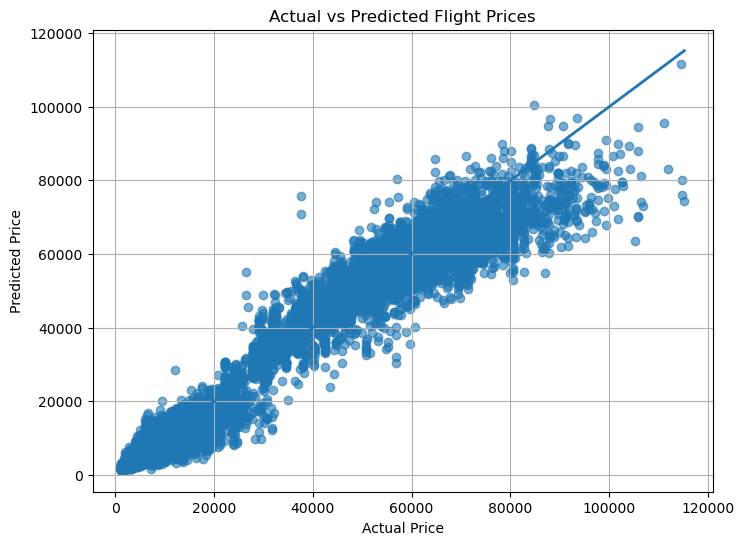

In [7]:
# =====================================================
# Actual vs Predicted Price Visualization
# =====================================================

plt.figure(figsize=(8, 6))

# Scatter Plot
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Ideal Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.title("Actual vs Predicted Flight Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()

# Residual Analysis

## Objective

Residual Analysis helps us understand the prediction errors made by the model.

A residual is calculated as:

**Residual = Actual Price − Predicted Price**

This analysis helps us:

- Identify underprediction and overprediction
- Detect systematic errors
- Check whether prediction errors are randomly distributed
- Validate the assumptions of a good regression model

A well-performing regression model should produce residuals that are randomly scattered around zero without any visible pattern.

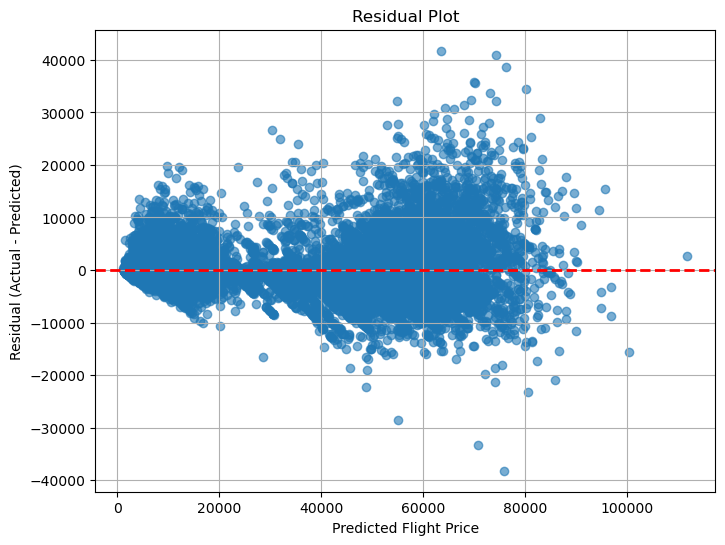

In [8]:
# =====================================================
# Residual Analysis
# =====================================================

# Calculate Residuals
residuals = y_test - y_pred

# Create Figure
plt.figure(figsize=(8,6))

# Scatter Plot
plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

# Horizontal Reference Line
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted Flight Price")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(True)

plt.show()

# Feature Importance Analysis

## Objective

Feature Importance helps us understand which input features have the greatest influence on the flight ticket price predictions.

Understanding feature importance allows us to:

- Identify the most influential variables
- Improve model interpretability
- Support business decision-making
- Guide future feature engineering

For tree-based models, feature importance represents the relative contribution of each feature to the prediction process.

,Feature,Importance
33,categorical__class_Business,0.843431
1,categorical__airline_Air_India,0.015735
35,numerical__duration,0.014370
29,categorical__destination_city_Delhi,0.008821
8,categorical__source_city_Delhi,0.008487
18,categorical__stops_one,0.007193
22,categorical__arrival_time_Early_Morning,0.007153
30,categorical__destination_city_Hyderabad,0.006340
10,categorical__source_city_Kolkata,0.006323
32,categorical__destination_city_Mumbai,0.006164


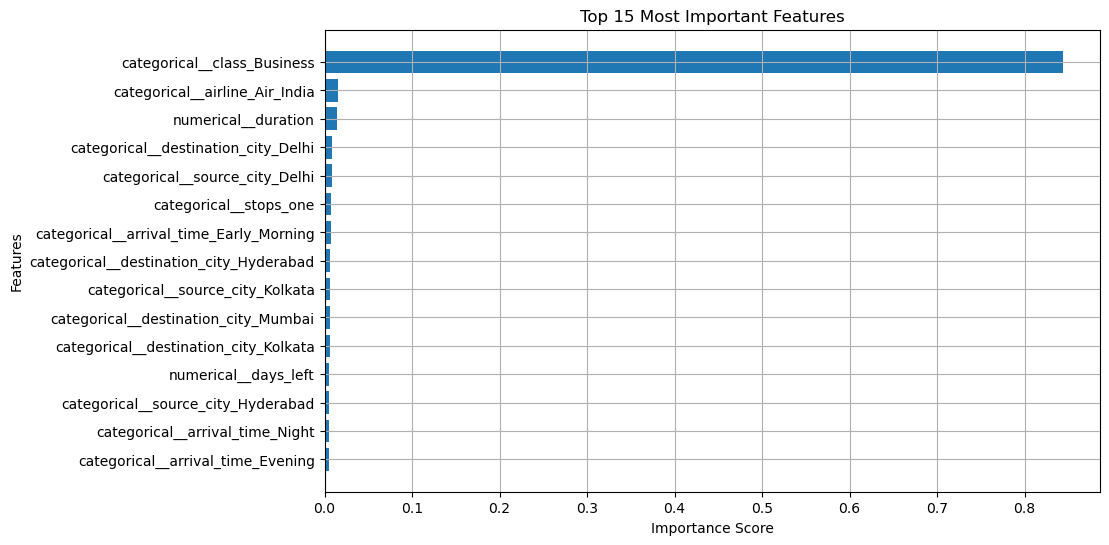

In [9]:
# =====================================================
# Feature Importance Analysis
# =====================================================

# Check whether the model supports feature importance
if hasattr(best_model, "feature_importances_"):

    # Get feature names from preprocessor
    feature_names = preprocessor.get_feature_names_out()

    # Create DataFrame
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_
    })

    # Sort by Importance
    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    # Display Top 15 Features
    display(importance_df.head(15))

    # Plot
    plt.figure(figsize=(10,6))

    plt.barh(
        importance_df.head(15)["Feature"][::-1],
        importance_df.head(15)["Importance"][::-1]
    )

    plt.title("Top 15 Most Important Features")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")

    plt.grid(True)

    plt.show()

else:
    print("The selected model does not provide feature_importances_.")

# SHAP Explainability

## Objective

SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to the model's predictions.

This analysis helps us:

- Understand individual predictions
- Measure each feature's contribution
- Increase model transparency
- Build trust in machine learning predictions

SHAP is one of the most widely used explainability techniques for tree-based machine learning models.

In [10]:
# =====================================================
# Install & Import SHAP
# =====================================================

# Uncomment if SHAP is not installed
! pip install shap

import shap

print("SHAP Imported Successfully.")

Defaulting to user installation because normal site-packages is not writeable
SHAP Imported Successfully.


In [11]:
# =====================================================
# Create SHAP Explainer
# =====================================================

# Create SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP Values
shap_values = explainer.shap_values(X_test_processed)

print("SHAP Values Calculated Successfully.")

SHAP Values Calculated Successfully.


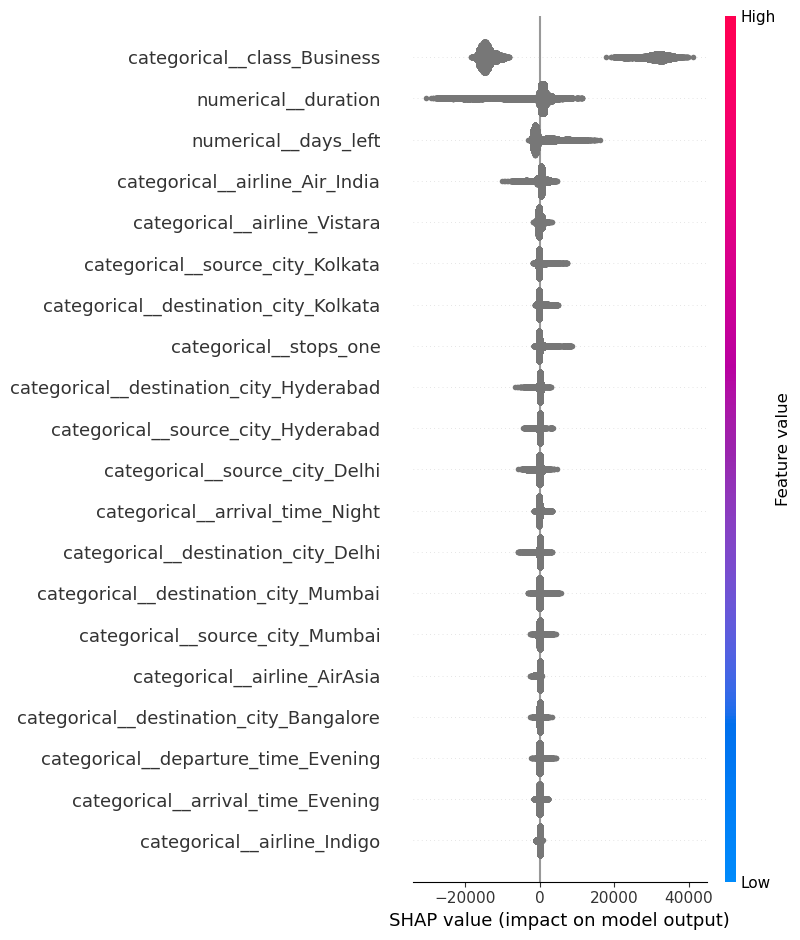

In [12]:
# =====================================================
# SHAP Summary Plot
# =====================================================

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=preprocessor.get_feature_names_out()
)

# Final Business Insights & Project Summary

## Objective

This notebook concludes the model evaluation and explainability phase.

The final summary includes:

- Model performance overview
- Key business insights
- Model strengths
- Model limitations
- Future improvements
- Deployment readiness

The purpose of this summary is to communicate the project findings to both technical and non-technical stakeholders.

In [13]:
# =====================================================
# Final Business Insights & Project Summary
# =====================================================

print("=" * 70)
print("Flight Ticket Price Prediction - Final Evaluation Summary")
print("=" * 70)

print("\nModel Performance")

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAPE     : {mape*100:.2f}%")

print("\nBusiness Insights")

print("• The trained model can estimate flight ticket prices using historical flight information.")
print("• Multiple machine learning algorithms were compared to identify the best-performing model.")
print("• Hyperparameter tuning improved the model's generalization performance.")
print("• Feature Importance and SHAP analysis increased model interpretability.")
print("• The model is suitable for deployment after successful evaluation.")

print("\nProject Strengths")

print("✔ End-to-End Machine Learning Pipeline")
print("✔ Data Cleaning & Feature Engineering")
print("✔ Multiple Model Comparison")
print("✔ Hyperparameter Tuning")
print("✔ Explainable AI (SHAP)")
print("✔ Production-Ready Artifacts")

print("\nLimitations")

print("• Predictions depend on historical data.")
print("• Unexpected market events may affect ticket prices.")
print("• Additional real-time features could further improve performance.")

print("\nFuture Improvements")

print("• Add real-time flight pricing APIs")
print("• Deploy using Streamlit")
print("• Build REST API using FastAPI")
print("• Deploy on AWS / Azure")
print("• Monitor model performance after deployment")

print("\nDeployment Status")

print("✔ Preprocessor Saved")
print("✔ Best Model Saved")
print("✔ Evaluation Completed")
print("✔ Explainability Completed")
print("✔ Ready for Deployment")

print("\n" + "=" * 70)
print("Notebook 5 Completed Successfully")
print("=" * 70)

Flight Ticket Price Prediction - Final Evaluation Summary

Model Performance
R² Score : 0.9829
MAE      : 1626.43
RMSE     : 2969.65
MAPE     : 11.95%

Business Insights
• The trained model can estimate flight ticket prices using historical flight information.
• Multiple machine learning algorithms were compared to identify the best-performing model.
• Hyperparameter tuning improved the model's generalization performance.
• Feature Importance and SHAP analysis increased model interpretability.
• The model is suitable for deployment after successful evaluation.

Project Strengths
✔ End-to-End Machine Learning Pipeline
✔ Data Cleaning & Feature Engineering
✔ Multiple Model Comparison
✔ Hyperparameter Tuning
✔ Explainable AI (SHAP)
✔ Production-Ready Artifacts

Limitations
• Predictions depend on historical data.
• Unexpected market events may affect ticket prices.
• Additional real-time features could further improve performance.

Future Improvements
• Add real-time flight pricing APIs
•